# Portfolio Part 3 - Analysis of Mobile Price Data (2024 S1)

In this Portfolio task, you will work on a new dataset named 'Mobile Price Data', it contains numerous details about mobile phone hardware, specifications, and prices. Your main task is to train classification models to predict **mobile phone prices** ('price range' in the dataset)and evaluate the strengths and weaknesses of these models.

Here's the explanation of each column:

|Column|Meaning|
|:-----:|:-----:|
|battery power|Total energy a battery can store in one time measured in mAh|
|blue|Has bluetooth or not|
|clock speed|speed at which microprocessor executes instructions|
|dual sim|Has dual sim support or not|
|fc|Front Camera mega pixels|
|four g|Has 4G or not|
|int memory|Internal Memory in Gigabytes|
|m dep|Mobile Depth in cm|
|mobile wt|Weight of mobile phone|
|n cores|Number of cores of processor|
|pc|Primary Camera mega pixels|
|px height|Pixel Resolution Height|
|px width|Pixel Resolution Width|
|ram|Random Access Memory in Mega Bytes|
|sc h|Screen Height of mobile in cm|
|sc w|Screen Width of mobile in cm|
|talk time|longest time that a single battery charge will last when you are|
|three g|Has 3G or not|
|touch screen|Has touch screen or not|
|wifi|Has wifi or not|
|price range|This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost)|

Blue, dual sim, four g, three g, touch screen, and wifi are all binary attributes, 0 for not and 1 for yes.

Your high level goal in this notebook is to build and evaluate predictive models for 'price range' from other available features. More specifically, you need to **complete the following major steps**:

1. ***Explore the data*** and ***clean the data if necessary***. For example, remove abnormal instanaces and replace missing values.

2. ***Study the correlation*** between 'price range' with other features. And ***select the variables*** that you think are helpful for predicting the price range. We do not limit the number of variables.

3. ***Split the dataset*** (Trainging set : Test set = 8 : 2)

4. ***Train a logistic regression model*** to predict 'price range' based on the selected features (from the second step). ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.) ***Explain your model and evaluate its performance*** (Is the model performing well? If yes, what factors might be contributing to the good performance of your model? If not, how can improvements be made?).

5. ***Train a KNN model*** to predict 'price range' based on the selected features (you can use the features selected from the second step and set K with an ad-hoc manner in this step. ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.)

6. ***Tune the hyper-parameter K*** in KNN (Hints: GridsearchCV), ***visualize the results***, and ***explain*** how K influences the prediction performance.

  Hints for visualization: You can use line chart to visualize K and mean accuracy scores on test set.

Note 1: In this assignment, we no longer provide specific guidance and templates for each sub task. You should learn how to properly comment your notebook by yourself to make your notebook file readable.

Note 2: You will not being evaluated on the accuracy of the model but on the process that you use to generate it and your explanation.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Step 1: Exploring and Preparing the Data

In [13]:
# 1.1 Load the dataset and show first 10 rows

data = pd.read_csv('/Users/macbook/Desktop/MQ/Session 1 - 2024/COMP2200 - Data Science/Portfolio/Portfolio 3/Mobile_Price_Data.csv')
data.head(10)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7.0,0.6,188,2,...,20,756.0,2549.0,9,7,19,0.0,0,1,1
1,1021,1,0.5,1,0,1,53.0,0.7,136,3,...,905,1988.0,2631.0,17,3,7,1.0,1,0,2
2,563,1,0.5,1,2,1,41.0,0.9,145,5,...,1263,1716.0,2603.0,11,2,9,1.0,1,0,2
3,615,1,2.5,0,0,0,10.0,0.8,131,6,...,1216,1786.0,2769.0,16,8,11,1.0,0,0,2
4,1821,1,1.2,0,13,1,44.0,0.6,141,2,...,1208,1212.0,1411.0,8,2,15,1.0,1,0,1
5,1859,0,0.5,1,3,0,22.0,0.7,164,1,...,1004,1654.0,1067.0,17,1,10,1.0,0,0,1
6,1821,0,1.7,0,4,1,10.0,0.8,139,8,...,381,1018.0,3220.0,13,8,18,1.0,0,1,3
7,1954,0,0.5,1,0,0,24.0,0.8,187,4,...,512,NaN,700.0,16,3,5,1.0,1,1,0
8,1445,1,0.5,0,0,0,53.0,0.7,174,7,...,386,836.0,1099.0,17,1,20,1.0,0,0,0
9,509,1,0.6,1,2,1,9.0,0.1,93,5,...,1137,1224.0,513.0,19,10,12,1.0,0,0,0


In [14]:
# 1.2 Show the shape of data

data.shape

(2000, 21)

In [37]:
# 1.3 Check the outliers

data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,1999.000000,1999.000000,2000.000000,2000.000000,...,2000.000000,1999.000000,1999.000000,2000.000000,2000.000000,2000.000000,1999.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.035018,0.501601,140.249000,4.520500,...,645.108000,1251.566783,2124.218609,12.306500,5.767000,11.011000,0.761381,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.142986,0.288411,35.399655,2.287837,...,443.780811,432.301505,1085.003435,4.213245,4.356398,5.463955,0.426346,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.500000,1207.000000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2147.000000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3065.000000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [46]:
# 1.4 Define the outliers by statistical method (find the IQR) and filter the outliers out

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

no_outliers_data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

print(no_outliers_data)

      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
1              1021     1          0.5         1   0       1        53.0   
2               563     1          0.5         1   2       1        41.0   
3               615     1          2.5         0   0       0        10.0   
4              1821     1          1.2         0  13       1        44.0   
5              1859     0          0.5         1   3       0        22.0   
...             ...   ...          ...       ...  ..     ...         ...   
1995            794     1          0.5         1   0       1         2.0   
1996           1965     1          2.6         1   0       0        39.0   
1997           1911     0          0.9         1   1       1        36.0   
1998           1512     0          0.9         0   4       1        46.0   
1999            510     1          2.0         1   5       1        45.0   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width     ram  sc_h  sc_w  \
1     

In [45]:
# 1.5 Recheck to make sure whether there are any missing values left

no_outliers_data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,1506.000000,1506.000000,1506.000000,1506.000000,1506.000000,1506.000000,1505.000000,1505.000000,1506.000000,1506.000000,...,1506.000000,1505.000000,1505.000000,1506.000000,1506.000000,1506.000000,1505.0,1506.000000,1506.000000,1506.000000
mean,1239.032537,0.486056,1.500797,0.505312,4.182603,0.684595,31.941528,0.499801,140.202523,4.507968,...,632.691235,1249.380066,2136.021262,12.344622,5.848606,10.867862,1.0,0.505976,0.505312,1.513944
std,439.152661,0.499972,0.813850,0.500138,4.215837,0.464831,18.214751,0.287841,35.143590,2.276619,...,435.280087,429.108016,1084.915173,4.213579,4.417835,5.433910,0.0,0.500130,0.500138,1.115939
min,501.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,1.0,0.000000,0.000000,0.000000
25%,852.000000,0.000000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,275.000000,877.000000,1223.000000,9.000000,2.000000,6.000000,1.0,0.000000,0.000000,1.000000
50%,1224.000000,0.000000,1.500000,1.000000,3.000000,1.000000,31.000000,0.500000,141.000000,4.000000,...,557.500000,1247.000000,2166.000000,12.000000,5.000000,11.000000,1.0,1.000000,1.000000,2.000000
75%,1618.500000,1.000000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,933.250000,1623.000000,3083.000000,16.000000,9.000000,15.000000,1.0,1.000000,1.000000,3.000000
max,1998.000000,1.000000,3.000000,1.000000,16.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1920.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.0,1.000000,1.000000,3.000000


In [41]:
# 1.6 Check the missing values 

no_outliers_data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       1
m_dep            1
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         1
ram              1
sc_h             0
sc_w             0
talk_time        0
three_g          1
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [48]:
# 1.7 Replace the missing values by the mean value
# Note: Because I have filtered out the outliers, That is why I use the mean values to replace the missing values

cleaned_data = no_outliers_data.fillna(no_outliers_data.mean())
cleaned_data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1,1021,1,0.5,1,0,1,53.0,0.7,136,3,...,905,1988.0,2631.0,17,3,7,1.0,1,0,2
2,563,1,0.5,1,2,1,41.0,0.9,145,5,...,1263,1716.0,2603.0,11,2,9,1.0,1,0,2
3,615,1,2.5,0,0,0,10.0,0.8,131,6,...,1216,1786.0,2769.0,16,8,11,1.0,0,0,2
4,1821,1,1.2,0,13,1,44.0,0.6,141,2,...,1208,1212.0,1411.0,8,2,15,1.0,1,0,1
5,1859,0,0.5,1,3,0,22.0,0.7,164,1,...,1004,1654.0,1067.0,17,1,10,1.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2.0,0.8,106,6,...,1222,1890.0,668.0,13,4,19,1.0,1,0,0
1996,1965,1,2.6,1,0,0,39.0,0.2,187,4,...,915,1965.0,2032.0,11,10,16,1.0,1,1,2
1997,1911,0,0.9,1,1,1,36.0,0.7,108,8,...,868,1632.0,3057.0,9,1,5,1.0,1,0,3
1998,1512,0,0.9,0,4,1,46.0,0.1,145,5,...,336,670.0,869.0,18,10,19,1.0,1,1,0


In [43]:
# 1.8 Recheck whether there are any missing values left

cleaned_data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

# Step 2: Finding the Correlation between 'Price Range' with other features.

In [49]:
# 2. Find the correlation between the price range with other features¶

correlation = cleaned_data.corr()

print(correlation['price_range'].sort_values(ascending=False))

price_range      1.000000
ram              0.917728
battery_power    0.198363
px_width         0.155964
px_height        0.139208
pc               0.047474
int_memory       0.039508
sc_w             0.034123
fc               0.027070
m_dep            0.016459
wifi             0.012963
blue             0.012853
sc_h             0.011201
talk_time        0.004523
n_cores          0.003618
dual_sim         0.002248
four_g           0.001439
clock_speed     -0.008426
mobile_wt       -0.021242
touch_screen    -0.028127
three_g               NaN
Name: price_range, dtype: float64


According to the correlation values comparing the price range with other features, it is obvious that **the most correlated feature with the price range is RAM**, as evidenced by a correlation value of **0.9177**. Therefore, RAM is likely the most significant feature affecting the price range. 

_However_, there are some features which have quite high correlation (higher than 10%), _hence_, I will use top 4 of the most correlated feautures to build the model for more accurate result, which are __ram, battery power, width, height.__

# Step 3: Split the Dataset

In [169]:
# 3.1 Select the top 4 correlated features to the price range, 
# based on the correlation values in Step 2, to build the model

features = ['ram', 'battery_power', 'px_width', 'px_height']
X = cleaned_data[features]
y = cleaned_data['price_range']

# 3.2 Split the dataset into training set and test set by provided ratio (Training set : Test set = 8 : 2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a Logistic Regression Model

In [170]:
# 4.1 Build up the logistic regression model

logistic_model = LogisticRegression(max_iter=500)

# 4.2 Train the logistic regression model

logistic_model.fit(X_train, y_train)

# 4.3 Predict the target variable for both training and test set by using the logistic regression model

y_train_predict_logistic = logistic_model.predict(X_train)
y_test_predict_logistic = logistic_model.predict(X_test)

# 4.4 Calculate the accuracy score for the logistic regression model

logistic_train_accuracy = accuracy_score(y_train, y_train_predict)
logistic_test_accuracy = accuracy_score(y_test, y_test_predict)

# 4.5 Print out

print("The Accuracy of Training data of the Logistic Regression Model is ", logistic_train_accuracy)
print("The Accuracy of Testing data of the Logistic Regression Model is", logistic_test_accuracy)

The Accuracy of Training data of the Logistic Regression Model is  0.9617940199335548
The Accuracy of Testing data of the Logistic Regression Model is 0.9602649006622517


- __1. Training Accuracy:__ The training accuracy of the model is approximately 96.18%. This high level of accuracy on the training set indicates that the model is highly effective at understanding and predicting the outcomes from the patterns that the model has learned from the training dataset.

- __2. Consistency with Test Accuracy:__ The testing accuracy is 96.03%. It is as high as the training data accuracy. This score also indicates that the model can understand and predict outcomes from new or unseen data nearly as well as it has performed on the training data.

- __3. Overfitting Risk:__ Since the test accuracy is almost as high as the training accuracy, therefore, there is a low risk of overfitting, and it shows that this model can be adapted to new or unseen data, not limited to only the training data. ___Note:___ _Overfitting occurs when the model experiences a lot of variance in the training dataset and negatively impacts the performance of the model on new data. It can be seen by a high accuracy rate in the training dataset but a low accuracy rate in the testing dataset._

- __4. Underfitting Risk:__ Since the accuracy scores on both training and testing data are high, underfitting does not appear to be a concern for this model, and it seems to be sufficiently complex to capture the essential patterns in the data. ___Note:___ _Underfitting occurs when the model experiences a lot of biases or the model might be too simple to capture underlying patterns in the training dataset and negatively impacts the performance of the model on both training and testing dataset. It can be seen by low accuracy rates in both training and testing dataset._

__Conclusion:__

Overall, this logistic regression model shows excellent performance and robustness. So, the model can understand and predict outcomes effectively, which can be seen by high accuracy scores on both training and testing datasets. Plus, there is minimal risk of both overfitting and underfitting.

_However, it is very important to always keep monitoring of the model, especially when it runs in a real application with a dynamic environment and diverse new or unseen datasets to ensure the model's consistency of prediction._

# Step 5: Train a KNN Model

In [171]:
# 5.1 Build up the KNN model with K=5 (the common k defualt)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 5.2 Train the KNN model
knn_model.fit(X_train, y_train)

# 5.3 Predict the target variable, based on the target variable on Step 2, 
# for training and testing data by using KNN model

y_train_predict_knn = knn_model.predict(X_train)
y_test_predict_knn = knn_model.predict(X_test)

# 5.4 Calculate the accuracy score for the KNN model
knn_train_accuracy = accuracy_score(y_train, y_train_predict_knn)
knn_test_accuracy = accuracy_score(y_test, y_test_predict_knn)

# 5.5 Print out the result
print("The Accuracy of Training data of the KNN Model is ", knn_train_accuracy)
print("The Accuracy of Testing data of the KNN Model is", knn_test_accuracy)

The Accuracy of Training data of the KNN Model is  0.9385382059800664
The Accuracy of Testing data of the KNN Model is 0.9337748344370861


1. __Training Accuracy of the KNN Model:__
The training accuracy of the KNN model is approximately 93.85%. This indicates that the model is quite effective in understanding and capturing the patterns in the training data and perform effectively in predicting the accurate outcomes. 

2. __Consistency with Test Accuracy of the KNN Model:__
The testing accuracy of the KNN model is approximately 93.38%, which is high and close to the training data accuracy. Due to a small difference between the training and test accuracies, it indicates that this model has well learned the patterns and relationships in the training data and it suggests that the model is applicable effectively to the new or unseen dataset.

3. __Overfitting Risk of the KNN Model:__
Overfitting happens when the model learns the training data too well, the learnings include the undesirable data which is high variance, and it leads to poor performance in prediction on new and unseen data. In this case, the training and testing dataset have just slightly different from each other, which means there is just a minimal risk of overfitting and this model can perform on the new or unseen dataset as well as it has done on the training dataset.


4. __Underfitting Risk of the KNN Model:__
Underfitting happens when the model is too simple to learn or capture the complex data which can be shown in the low accuracy rate. In this case, both accuracy rates of training and testing data are close to 94%, which are quite high. Therefore, there is no indication of underfitting in this model and the model seems to have enough complexity to capture the essential patterns without being too simplistic.

__Conclusion:__

_Overall_, this KNN model demonstrates robust performance with high accuracy on both the training and testing datasets, good generalisation capabilities, and no significant signs of overfitting or underfitting risks. These high rates of accuracy indicate that the model is well-tuned for the dataset (with K=5), providing a good balance between bias and variance. 

_However, for the better result, we can check whether there is some better K values that is able to generate a better accuracy rate in this model. This is called the 'Tuning the hyper-parameter K' method and I will show in the next step._

# Step 6: Tune the hyper-parameter K in KNN


__Step 6.1: Finding the best K Values by using the GridSearchCV function__

In [172]:
# 6.1.1 Define the parameter grid for 'n_neighbors'
parameter_grid = {'n_neighbors': np.arange(1, 30)}

# 6.1.2 Define the GridSearchCV variable
knn_gscv = GridSearchCV(KNeighborsClassifier(), parameter_grid, scoring='accuracy', cv=5)

# 6.1.3 Fit the GridSearchCV model to the training data
knn_gscv.fit(X_train, y_train)

# 6.1.4 Finding the best K value and the best K accuracy
best_k_value = knn_gscv.best_params_['n_neighbors']
best_k_accuracy = knn_gscv.best_score_

# 6.1.5 Use the best K value and the best accuracy of the model to see the best results
best_knn_model = KNeighborsClassifier(n_neighbors=best_k_value)
best_knn_model.fit(X_train, y_train)
best_y_test_predict = best_knn_model.predict(X_test)
best_test_accuracy = accuracy_score(y_test, best_y_test_predict)

# 6.1.6 Print out the result
print("The Best K value of this KNN Model is ", best_k_value)
print("The Best K Accuracy of this KNN Model is ", best_k_accuracy)
print("The Best Accuracy of this testing data of this KNN Model is ", best_test_accuracy)

The Best K value of this KNN Model is  15
The Best K Accuracy of this KNN Model is  0.922731673582296
The Best Accuracy of this testing data of this KNN Model is  0.9238410596026491


To evaluate the performance of the KNN model, choosing the right number of neighbors (K) is vital for the model's ability to perform effectively. In this step, I am determining the best K value for this KNN model, and I have found:

__1. The Best K Value:__ The optimal number of neighbors (K value) is 15. It suggests that this model achieves the best balance between bias and variance and well-tuned to perform effectively at this K value.

__2. The Best K Accuracy:__ The best accuracy at K=15 is 92.27%. This accuracy rate is the highest. It indicates that the model can capture the underlying patterns in the training dataset effectively and capable of making accurate predictions on new and unseen data (the testing dataset).

__3. Testing Data Accuracy:__ The best accuracy on the testing data is 92.38%, it is very close to the training dataset accuracy. This small difference between training and testing accuracy indicates that this model is robust in its predictions and able to generalise effectively to new and unseen data. Also, these close values imply that the model is neither overfitting nor underfitting significantly.

__Step 6.2: Visualisation and Explaination the Result__

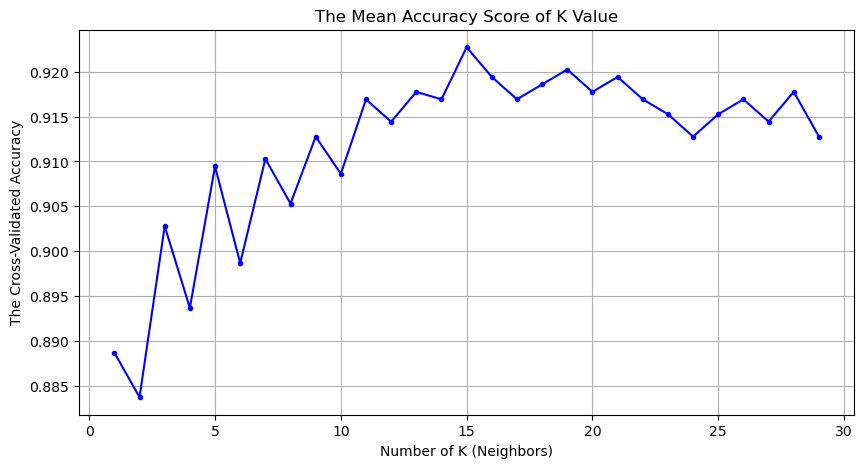

In [174]:
# 6.2.1. Calculate the mean of test scores for each parameter setting in the GridSearchCV
mean_test_score = knn_gscv.cv_results_['mean_test_score']

# 6.2.2. Visualise the result
plt.figure(figsize=(10, 5))
plt.plot(parameter_grid['n_neighbors'], mean_test_score, marker='.',color='blue')
plt.title('The Mean Accuracy Score of K Value')
plt.xlabel('Number of K (Neighbors)')
plt.ylabel('The Cross-Validated Accuracy')
plt.grid(True)
plt.show()

This graph visualises the cross-validated accuracy of a K-Nearest Neighbors (KNN) model for different values of 
K, which is the number of neighbors considered for making predictions. The graph shows:

- __1. Initial Rise:__ From K=1 to K=5, the accuracy rapidly increases. This suggests that the low K values are not sufficient to make the most accurate predictions, likely due to overfitting, where the model is too sensitive to noise in the training data.

- __2. Steadily Rise:__ From K=5 to K=15, the accuracy is steadily rises. This suggests that the model is finding the best K value that can generate the highest accuracy rate but have not found yet.

- __3. Peak Accuracy:__ The accuracy peaks at K=15. This indicates that at K=15, the model has the highest accuracy rate and the most effective at learning and capturing patterns from training dataset and the model can predict the most accurate outcomes in this K value.

- __4. Gradual Drop:__ After the peak, the accuracy seems to quite high but gradually drops. This suggests that the model might gradually start to be underfitted. This decrease happens when it may have too many neighbors, introduces too much generalisation and possibly experiences the irrelevant neighbors. 

__Overall Trend:__ The accuracy continuously increases before it reaches the peak at K=15 and the accuracy does not drastically decrease after reaching the peak, which implies that the model's performance is relatively stable even with a higher number of neighbors. _However, beyond the peak K value, the addition of more neighbors does not seem to significantly improve the model performance._

__In conclusion__, _this graph shows the accuracy rate of different number of K values which represents the trade-off between a too complex model (low K) and a too simplistic model (high K), helping to find a balance that yields the most accurate predictions on unseen data. The graph shows that K=15 is the best K value for this model and K=15 is the best choice to use to generate the most accurate predictions for this KNN model._